# 06a — Headline Results & Comparison Tables (v1.0-trainval, 5-fold)
## Multi-Attribute Scene Classification on nuScenes — Primary Experiment

This notebook draws the **primary headline results** for the 150-scene subset (Stage 2) — the
trustworthy dataset on which conclusions are based. Stage 1 (v1.0-mini) served as the pilot;
its analysis lives in `notebooks/v1.0-mini/08a-c`.

**Reads** saved results (no retraining): `results/v1.0-trainval/metrics/{all_metrics,baseline_metrics}.csv`.
**Produces** headline tables in `results/v1.0-trainval/final/`.


## 0. Setup

In [1]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score

def find_project_root():
    p = __import__('pathlib').Path.cwd().resolve()
    for cand in [p, *p.parents]:
        if (cand/'README.md').exists() and (cand/'notebooks').exists(): return cand
    raise FileNotFoundError('Project root not found')
from pathlib import Path
os.chdir(find_project_root())

sns.set_theme(style='whitegrid', context='notebook'); plt.rcParams['figure.dpi']=100
DATASET_VERSION='v1.0-trainval'
RESULTS_DIR = Path('results')/DATASET_VERSION/'metrics'
PRED_DIR    = Path('results')/DATASET_VERSION/'predictions'
FINAL_DIR   = Path('results')/DATASET_VERSION/'final'; FINAL_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR     = Path('results')/DATASET_VERSION/'figures'/'final'; FIG_DIR.mkdir(parents=True, exist_ok=True)
ATTRIBUTES=['time_of_day','weather','vehicle_density','vru_present']
CLASS_ORDERS={'time_of_day':['day','night'],'weather':['clear','rain'],
              'vehicle_density':['low','medium','high'],'vru_present':['absent','present']}
DISPLAY={'LogisticRegression':'LogReg','SVM_RBF':'SVM','RandomForest':'RF','XGBoost':'XGB','MLP':'MLP'}
print('Setup OK |', os.getcwd())

Setup OK | C:\Users\leemi\Documents\GitHub\nuscenes-scene-classification-ml


## 1. Load Inputs (saved 5-fold results)

In [2]:
df_metrics   = pd.read_csv(RESULTS_DIR/'all_metrics.csv')
df_baselines = pd.read_csv(RESULTS_DIR/'baseline_metrics.csv')
# trainval: every row is a test-fold result (no 'split' column). Tuned subset:
tuned = df_metrics[df_metrics['version']=='tuned'].copy()
print(f'metrics rows: {len(df_metrics)} | tuned rows: {len(tuned)}')
print(f'attributes: {sorted(df_metrics.attribute.unique())}')
print(f'folds: {sorted(df_metrics.fold.unique())} | seeds: {sorted(df_metrics.seed.unique())}')

metrics rows: 600 | tuned rows: 300
attributes: ['time_of_day', 'vehicle_density', 'vru_present', 'weather']
folds: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)] | seeds: [np.int64(7), np.int64(42), np.int64(123)]


## 2. Headline Table — Best Tuned Model per Attribute

In [3]:
rows=[]
for attr in ATTRIBUTES:
    sub=tuned[tuned.attribute==attr]
    g=sub.groupby('model')['macro_f1'].agg(['mean','std']).reset_index()
    if g.empty: continue
    best=g.loc[g['mean'].idxmax()]
    rnd=df_baselines[(df_baselines.attribute==attr)&(df_baselines.baseline=='random')]['macro_f1'].mean()
    maj=df_baselines[(df_baselines.attribute==attr)&(df_baselines.baseline=='majority')]['macro_f1'].mean()
    rows.append({'attribute':attr,'best_model':DISPLAY.get(best['model'],best['model']),
                 'macro_f1':round(best['mean'],3),'std':round(best['std'],3),
                 'random':round(rnd,3),'majority':round(maj,3),
                 'beats_random':best['mean']>rnd,'beats_majority':best['mean']>maj})
headline=pd.DataFrame(rows)
headline.to_csv(FINAL_DIR/'headline_table.csv',index=False)
print('=== HEADLINE: BEST TUNED MODEL PER ATTRIBUTE (v1.0-trainval) ===')
print(headline.to_string(index=False))

=== HEADLINE: BEST TUNED MODEL PER ATTRIBUTE (v1.0-trainval) ===
      attribute best_model  macro_f1   std  random  majority  beats_random  beats_majority
    time_of_day        XGB     0.993 0.012   0.452     0.444          True            True
        weather         RF     0.901 0.068   0.446     0.443          True            True
vehicle_density        SVM     0.511 0.022   0.330     0.168          True            True
    vru_present        SVM     0.628 0.033   0.498     0.346          True            True


## 3. All-Results Matrix (model × attribute, tuned mean macro-F1)

=== ALL MODELS x ATTRIBUTES (tuned macro-F1) ===
attribute  time_of_day  weather  vehicle_density  vru_present
model                                                        
LogReg           0.993    0.858            0.486        0.601
MLP              0.969    0.850            0.489        0.615
RF               0.976    0.901            0.442        0.599
SVM              0.978    0.876            0.511        0.628
XGB              0.993    0.896            0.506        0.617


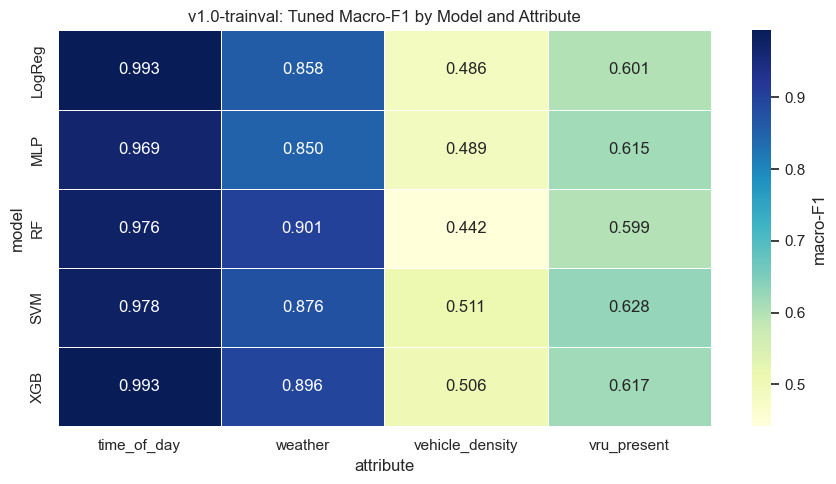

In [4]:
matrix=(tuned.groupby(['model','attribute'])['macro_f1'].mean().unstack('attribute')
        .reindex(columns=ATTRIBUTES))
matrix.index=matrix.index.map(lambda m: DISPLAY.get(m,m))
matrix=matrix.round(3)
matrix.to_csv(FINAL_DIR/'all_results_matrix.csv')
print('=== ALL MODELS x ATTRIBUTES (tuned macro-F1) ==='); print(matrix)

fig,ax=plt.subplots(figsize=(9,5))
sns.heatmap(matrix,annot=True,fmt='.3f',cmap='YlGnBu',cbar_kws={'label':'macro-F1'},ax=ax,linewidths=.5)
ax.set_title('v1.0-trainval: Tuned Macro-F1 by Model and Attribute'); plt.tight_layout()
plt.savefig(FIG_DIR/'results_matrix_heatmap.png',bbox_inches='tight',dpi=120); plt.show()

## 4. Cross-Attribute Model Ranking

In [5]:
ranking=(tuned.groupby('model')['macro_f1'].agg(['mean','std']).round(3)
         .sort_values('mean',ascending=False))
ranking.index=ranking.index.map(lambda m: DISPLAY.get(m,m))
print('=== MODEL RANKING (mean macro-F1 across all attributes/folds/seeds) ===')
print(ranking)

=== MODEL RANKING (mean macro-F1 across all attributes/folds/seeds) ===
         mean    std
model               
XGB     0.753  0.203
SVM     0.748  0.192
LogReg  0.735  0.206
MLP     0.731  0.194
RF      0.729  0.225


## 5. Top-3 Models Per Attribute

In [6]:
top3=[]
for attr in ATTRIBUTES:
    g=(tuned[tuned.attribute==attr].groupby('model')['macro_f1'].mean()
       .sort_values(ascending=False).head(3))
    for rank,(m,v) in enumerate(g.items(),1):
        top3.append({'attribute':attr,'rank':rank,'model':DISPLAY.get(m,m),'macro_f1':round(v,3)})
df_top3=pd.DataFrame(top3); df_top3.to_csv(FINAL_DIR/'top3_per_attribute.csv',index=False)
print(df_top3.to_string(index=False))

      attribute  rank  model  macro_f1
    time_of_day     1    XGB     0.993
    time_of_day     2 LogReg     0.993
    time_of_day     3    SVM     0.978
        weather     1     RF     0.901
        weather     2    XGB     0.896
        weather     3    SVM     0.876
vehicle_density     1    SVM     0.511
vehicle_density     2    XGB     0.506
vehicle_density     3    MLP     0.489
    vru_present     1    SVM     0.628
    vru_present     2    XGB     0.617
    vru_present     3    MLP     0.615


## 6. Per-Class Precision & Recall (Best Model per Attribute)

Computed from saved out-of-fold predictions (seed 42, all folds aggregated).

In [7]:
df_preds=pd.read_csv(PRED_DIR/'predictions_test.csv')
name_to_full={v:k for k,v in DISPLAY.items()}
pr_rows=[]
for attr in ATTRIBUTES:
    if attr not in headline.attribute.values: continue
    best_short=headline[headline.attribute==attr]['best_model'].iloc[0]
    best_full=name_to_full[best_short]
    sub=df_preds[(df_preds.attribute==attr)&(df_preds.model==best_full)&
                 (df_preds.version=='tuned')&(df_preds.seed==42)]
    if len(sub)==0: continue
    classes=CLASS_ORDERS[attr]
    p=precision_score(sub.y_true,sub.y_pred,labels=classes,average=None,zero_division=0)
    r=recall_score(sub.y_true,sub.y_pred,labels=classes,average=None,zero_division=0)
    for cls,pp,rr in zip(classes,p,r):
        pr_rows.append({'attribute':attr,'model':best_short,'class':cls,
                        'precision':round(pp,3),'recall':round(rr,3)})
df_pr=pd.DataFrame(pr_rows); df_pr.to_csv(FINAL_DIR/'recall_precision_best.csv',index=False)
print('=== PER-CLASS PRECISION / RECALL (best model, OOF seed 42) ===')
print(df_pr.to_string(index=False))

=== PER-CLASS PRECISION / RECALL (best model, OOF seed 42) ===
      attribute model   class  precision  recall
    time_of_day   XGB     day      0.995   0.999
    time_of_day   XGB   night      0.997   0.982
        weather    RF   clear      0.945   0.987
        weather    RF    rain      0.936   0.770
vehicle_density   SVM     low      0.568   0.628
vehicle_density   SVM  medium      0.431   0.423
vehicle_density   SVM    high      0.574   0.506
    vru_present   SVM  absent      0.642   0.711
    vru_present   SVM present      0.626   0.550


## 7. Fold-by-Fold Breakdown (transparency)

In [8]:
fold_rows=[]
for attr in ATTRIBUTES:
    if attr not in headline.attribute.values: continue
    best_short=headline[headline.attribute==attr]['best_model'].iloc[0]
    best_full=name_to_full[best_short]
    sub=tuned[(tuned.attribute==attr)&(tuned.model==best_full)]
    for f in sorted(sub.fold.unique()):
        fv=sub[sub.fold==f]['macro_f1']
        fold_rows.append({'attribute':attr,'model':best_short,'fold':int(f),
                          'macro_f1_mean':round(fv.mean(),3),'macro_f1_std':round(fv.std(),3)})
df_fold=pd.DataFrame(fold_rows); df_fold.to_csv(FINAL_DIR/'fold_breakdown_best.csv',index=False)
print(df_fold.to_string(index=False))

      attribute model  fold  macro_f1_mean  macro_f1_std
    time_of_day   XGB     0          0.996         0.000
    time_of_day   XGB     1          1.000         0.000
    time_of_day   XGB     2          1.000         0.000
    time_of_day   XGB     3          1.000         0.000
    time_of_day   XGB     4          0.970         0.002
        weather    RF     0          0.968         0.003
        weather    RF     1          0.804         0.019
        weather    RF     2          0.931         0.004
        weather    RF     3          0.956         0.001
        weather    RF     4          0.844         0.009
vehicle_density   SVM     0          0.508         0.000
vehicle_density   SVM     1          0.517         0.000
vehicle_density   SVM     2          0.474         0.000
vehicle_density   SVM     3          0.517         0.000
vehicle_density   SVM     4          0.539         0.000
    vru_present   SVM     0          0.576         0.000
    vru_present   SVM     1    

## 8. Headline Summary JSON

In [9]:
summary={'dataset_version':DATASET_VERSION,
         'best_per_attribute':{r['attribute']:{'model':r['best_model'],'macro_f1':r['macro_f1'],
            'std':r['std'],'beats_random':bool(r['beats_random']),
            'beats_majority':bool(r['beats_majority'])} for _,r in headline.iterrows()},
         'model_ranking':{m:float(v) for m,v in ranking['mean'].items()}}
with open(FINAL_DIR/'headline_summary.json','w') as f: json.dump(summary,f,indent=2)
print('Saved ->',FINAL_DIR/'headline_summary.json'); print(json.dumps(summary,indent=2))

Saved -> results\v1.0-trainval\final\headline_summary.json
{
  "dataset_version": "v1.0-trainval",
  "best_per_attribute": {
    "time_of_day": {
      "model": "XGB",
      "macro_f1": 0.993,
      "std": 0.012,
      "beats_random": true,
      "beats_majority": true
    },
    "weather": {
      "model": "RF",
      "macro_f1": 0.901,
      "std": 0.068,
      "beats_random": true,
      "beats_majority": true
    },
    "vehicle_density": {
      "model": "SVM",
      "macro_f1": 0.511,
      "std": 0.022,
      "beats_random": true,
      "beats_majority": true
    },
    "vru_present": {
      "model": "SVM",
      "macro_f1": 0.628,
      "std": 0.033,
      "beats_random": true,
      "beats_majority": true
    }
  },
  "model_ranking": {
    "XGB": 0.753,
    "SVM": 0.748,
    "LogReg": 0.735,
    "MLP": 0.731,
    "RF": 0.729
  }
}


## Findings (write in your own words)
[WRITE: best model per attribute; the photometric-vs-structural split; that all attributes beat
random and majority baselines; which model ranks most consistent overall.]